In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.iloc[:,1:]
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()

In [7]:
df['Species'] = encoder.fit_transform(df['Species'])

In [8]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [11]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

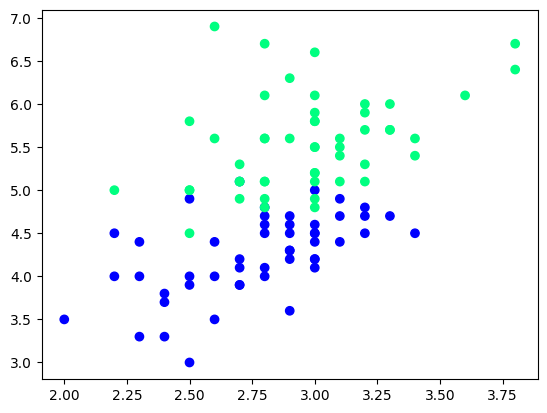

In [15]:
plt.scatter(x=df['SepalWidthCm'],y=df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [16]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
109,3.6,6.1,2
59,2.7,3.9,1
69,2.5,3.9,1
67,2.7,4.1,1
90,2.6,4.4,1
60,2.0,3.5,1
105,3.0,6.6,2
62,2.2,4.0,1
102,3.0,5.9,2


In [17]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,SepalWidthCm,PetalLengthCm,Species
122,2.8,6.7,2
51,3.2,4.5,1
105,3.0,6.6,2
110,3.2,5.1,2
70,3.2,4.8,1
107,2.9,6.3,2
141,3.1,5.1,2
74,2.9,4.3,1
96,2.9,4.2,1
118,2.6,6.9,2


In [19]:
df_val

,SepalWidthCm,PetalLengthCm,Species
99,2.8,4.1,1
129,3.0,5.8,2
72,2.5,4.9,1
95,3.0,4.2,1
69,2.5,3.9,1


In [20]:
df_test

,SepalWidthCm,PetalLengthCm,Species
78,2.9,4.5,1
57,2.4,3.3,1
109,3.6,6.1,2
97,2.9,4.3,1
98,2.5,3.0,1


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [22]:
y_test

array([1, 2, 1, 1, 1])

# Case 1 - Bagging

In [23]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
107,2.9,6.3,2
96,2.9,4.2,1
110,3.2,5.1,2
141,3.1,5.1,2
70,3.2,4.8,1
70,3.2,4.8,1
107,2.9,6.3,2


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

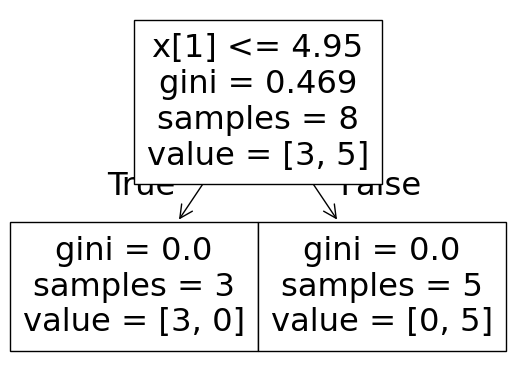

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


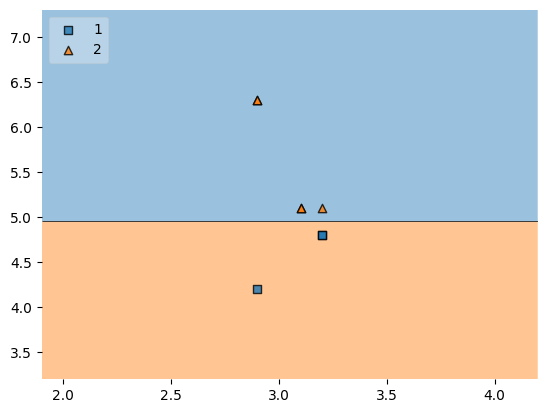

In [28]:
evaluate(dt_bag1,X,y)

In [30]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
105,3.0,6.6,2
118,2.6,6.9,2
74,2.9,4.3,1
74,2.9,4.3,1
110,3.2,5.1,2
122,2.8,6.7,2
122,2.8,6.7,2
70,3.2,4.8,1


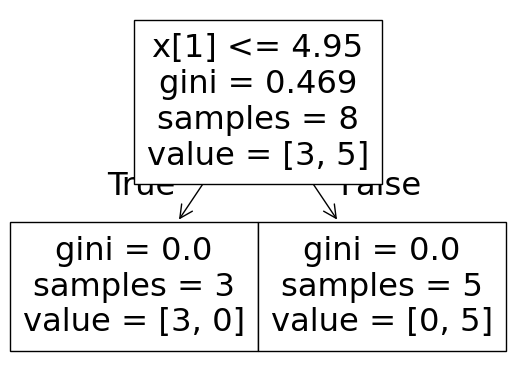

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


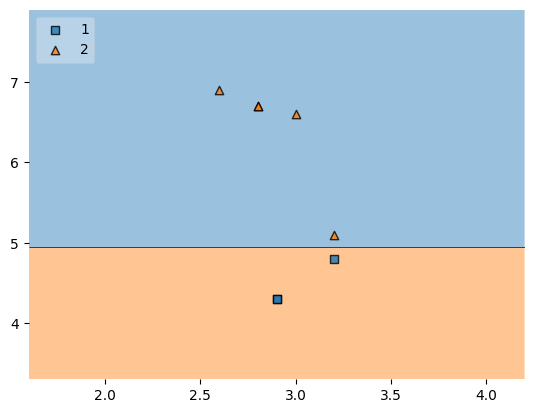

In [31]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [35]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
51,3.2,4.5,1
141,3.1,5.1,2
122,2.8,6.7,2
107,2.9,6.3,2
105,3.0,6.6,2
74,2.9,4.3,1
51,3.2,4.5,1


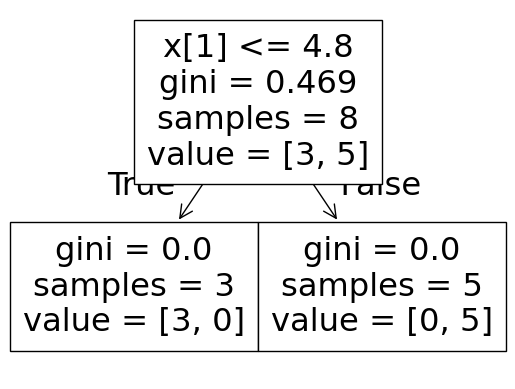

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


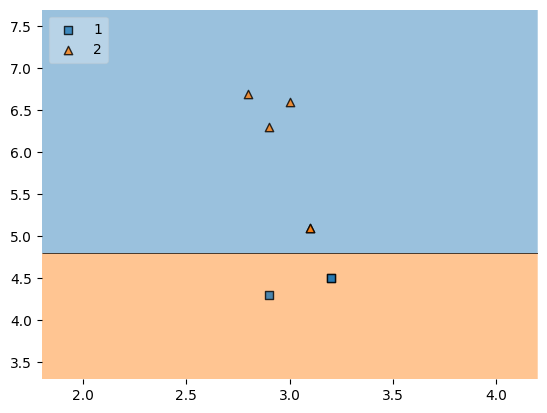

In [40]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [41]:
df_test

,SepalWidthCm,PetalLengthCm,Species
78,2.9,4.5,1
57,2.4,3.3,1
109,3.6,6.1,2
97,2.9,4.3,1
98,2.5,3.0,1


In [42]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [51]:
print("Predictor 1",dt_bag1.predict(np.array([1.1,5.7]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([1.1,5.7]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([1.1,5.7]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
